In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("data.csv")

df.shape

(569, 33)

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [6]:
print(df.columns)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [9]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [10]:
feature_column = [ 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean']
target_column  = 'diagnosis'

In [11]:
print(f"Feature Columns: {feature_column}")
print(f"Target Column: {target_column}")

Feature Columns: ['area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean']
Target Column: diagnosis


In [12]:
df[feature_column]

,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,1001.0,0.11840,0.27760,0.30010,0.14710
1,1326.0,0.08474,0.07864,0.08690,0.07017
2,1203.0,0.10960,0.15990,0.19740,0.12790
3,386.1,0.14250,0.28390,0.24140,0.10520
4,1297.0,0.10030,0.13280,0.19800,0.10430
...,...,...,...,...,...
564,1479.0,0.11100,0.11590,0.24390,0.13890
565,1261.0,0.09780,0.10340,0.14400,0.09791
566,858.1,0.08455,0.10230,0.09251,0.05302
567,1265.0,0.11780,0.27700,0.35140,0.15200


In [13]:
df[target_column]

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [ ]:

train, test = train_test_split(df, test_size=.2, random_state=42)

In [15]:
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

Train Shape: (455, 33)
Test Shape: (114, 33)


In [16]:
train_x = train[feature_column]
train_y = train[target_column]

test_x = test[feature_column]
test_y = test[target_column]

In [17]:
print("Feature Columns:")
print(train_x.columns)

print("\nTarget Column:")
print(train_y.name)  # if target_column is a single column

Feature Columns:
Index(['area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean'],
      dtype='object')

Target Column:
diagnosis


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(train_x, train_y)

LogisticRegression()

In [ ]:
# weights — how much each feature affects the prediction.
model.coef_

array([[0.01001591, 0.61949953, 1.95392408, 2.69684832, 1.20585576]])

In [ ]:
# starting value before any feature affects the prediction.
model.intercept_

array([-7.43063438])

In [21]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(model.predict(train_x), train_y)

print("Train Accuracy:", train_accuracy)

Train Accuracy: 0.8857142857142857


In [22]:
y_pred = model.predict(test_x)
accuracy_score(y_pred, test_y)

0.9298245614035088

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

confusion = confusion_matrix(test_y, y_pred)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[70  1]
 [ 7 36]]


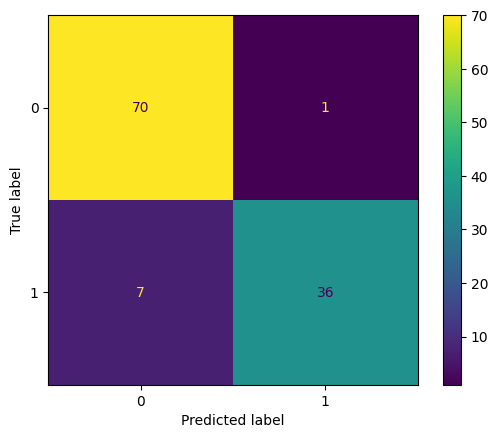

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay(confusion_matrix=confusion)
disp.plot()
